Created on Thursday October 01 2026

@author: Diego Alberto Olvera Millán

In [1]:
import numpy as np

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.quantum_info import Statevector

from qiskit_algorithms import NumPyMinimumEigensolver

from qiskit_nature.second_q.algorithms import GroundStateEigensolver
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit_nature.second_q.circuit.library import HartreeFock, UCCSD
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer


from qadaptive import (
    AdaptiveAnsatz,
    MutableAnsatzExperiment,
    InnerLoopTrainer,
    InnerLoopRecorder,
)

from qadaptive.core.operator_pool import PoolBlock
from qadaptive.outer import (
    ActionSpec,
    OuterStepPlan,
    default_append_index_policy,
)
from qadaptive.outer.action_definitions import INSERT_BLOCK
from qadaptive.training import ADAM

# ADAPT-VQE with QAdaptive

## 1. Electronic-structure problem

We first define a molecular electronic-structure problem using Qiskit Nature and
map the resulting fermionic Hamiltonian to qubits with the Jordan–Wigner
transformation.

The purpose of this notebook is not to introduce a new ADAPT-VQE variant, but to
show that the ADAPT-VQE algorithm can be expressed using QAdaptive's generic
adaptive-circuit abstractions.

The workflow is:

1. construct a molecular Hamiltonian;
2. generate a pool of fermionic single- and double-excitation operators;
3. expose those operators to QAdaptive as parametrized circuit blocks;
4. define the ADAPT operator-selection rule;
5. let QAdaptive handle ansatz growth, parameter optimization, history tracking,
   and termination.

To keep the example lightweight, we treat LiH in the STO-3G basis within an active 
space of 2 electrons in 3 spatial orbitals. The Li 1s orbital is frozen, and only 
orbitals of σ symmetry (indices 1, 2 and 5) are kept active. The remaining two 
orbitals form a degenerate π pair that does not couple to the σ ground state, so 
including only one of them, as the default orbital selection would, adds qubits 
without adding physics. The resulting problem has 6 qubits and an 8-operator 
excitation pool.

In [2]:
driver = PySCFDriver(
    atom="Li 0 0 0; H 0 0 1.6",
    basis="sto-3g",
)
full_problem = driver.run()

transformer = ActiveSpaceTransformer(
    num_electrons=2,
    num_spatial_orbitals=3,
    active_orbitals=[1, 2, 5],  # σ orbitals only; see note below
)
problem = transformer.transform(full_problem)

mapper = JordanWignerMapper()

hamiltonian = mapper.map(
    problem.hamiltonian.second_q_op()
)

num_qubits = hamiltonian.num_qubits

print("Spatial orbitals:", problem.num_spatial_orbitals)
print("Orbital energies", full_problem.orbital_energies)
print("Particles:", problem.num_particles)
print("Qubits:", num_qubits)

Spatial orbitals: 3
Orbital energies [-2.34876193 -0.28527077  0.07821657  0.16394135  0.16394135  0.54770839]
Particles: (1, 1)
Qubits: 6


### Hartree–Fock reference state

ADAPT-VQE starts from a reference state and grows the variational ansatz
iteratively.

For molecular problems, the Hartree–Fock state provides the natural initial
reference. At this stage the circuit contains no variational parameters; all
trainable parameters will be introduced by the adaptive procedure.

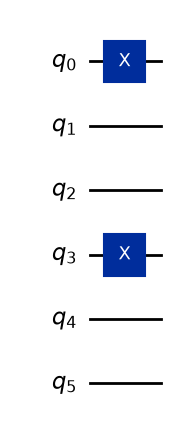

In [3]:
hf_state = HartreeFock(
    problem.num_spatial_orbitals,
    problem.num_particles,
    mapper,
)

hf_state.draw("mpl")

## 2. ADAPT operator pool

The original ADAPT-VQE procedure grows the ansatz by selecting operators from a
predefined pool according to their energy gradients.

Here we use the single- and double-excitation operators generated by Qiskit
Nature's `UCCSD` ansatz. Qiskit Nature is used only to construct the
chemistry-specific excitation pool; the adaptive optimization itself is
implemented through QAdaptive.

Importantly, operators are **not removed from the pool after selection**. The
same excitation may therefore be selected again at a later ADAPT iteration, as
in the original algorithm.

In [4]:
uccsd = UCCSD(
    problem.num_spatial_orbitals,
    problem.num_particles,
    mapper,
)

excitation_operators = uccsd.operators
excitation_labels = uccsd.excitation_list

print(f"Pool size: {len(excitation_operators)}")

for i, (excitation, operator) in enumerate(
    zip(excitation_labels, excitation_operators)
):
    print(i, excitation)
    print(operator)

Pool size: 8
0 ((0,), (1,))
SparsePauliOp(['IIIIXY', 'IIIIYX'],
              coeffs=[ 0.5+0.j, -0.5+0.j])
1 ((0,), (2,))
SparsePauliOp(['IIIXZY', 'IIIYZX'],
              coeffs=[ 0.5+0.j, -0.5+0.j])
2 ((3,), (4,))
SparsePauliOp(['IXYIII', 'IYXIII'],
              coeffs=[ 0.5+0.j, -0.5+0.j])
3 ((3,), (5,))
SparsePauliOp(['XZYIII', 'YZXIII'],
              coeffs=[ 0.5+0.j, -0.5+0.j])
4 ((0, 3), (1, 4))
SparsePauliOp(['IYYIXY', 'IXYIYY', 'IXXIXY', 'IYXIYY', 'IXYIXX', 'IYYIYX', 'IYXIXX', 'IXXIYX'],
              coeffs=[-0.125+0.j, -0.125+0.j, -0.125+0.j,  0.125+0.j, -0.125+0.j,  0.125+0.j,
  0.125+0.j,  0.125+0.j])
5 ((0, 3), (1, 5))
SparsePauliOp(['YZYIXY', 'XZYIYY', 'XZXIXY', 'YZXIYY', 'XZYIXX', 'YZYIYX', 'YZXIXX', 'XZXIYX'],
              coeffs=[-0.125+0.j, -0.125+0.j, -0.125+0.j,  0.125+0.j, -0.125+0.j,  0.125+0.j,
  0.125+0.j,  0.125+0.j])
6 ((0, 3), (2, 4))
SparsePauliOp(['IYYXZY', 'IXYYZY', 'IXXXZY', 'IYXYZY', 'IXYXZX', 'IYYYZX', 'IYXXZX', 'IXXYZX'],
              coeffs=[-0.1

## 3. Representing ADAPT excitations as QAdaptive blocks

QAdaptive does not need to know what a fermionic excitation is.

Its operator pool is built from generic `PoolBlock` objects: parametrized
circuit-building functions with a known qubit and parameter count. We therefore
wrap every mapped excitation operator in a one-parameter Pauli-evolution circuit,

$$
U_i(\theta_i) = e^{-i\theta_i P_i},
$$

where $P_i$ is the qubit operator associated with excitation $i$.

This translation is the interface between the chemistry-specific ADAPT operator
pool and QAdaptive's general circuit-adaptation machinery.

In [5]:
def make_evolution_block(
    name: str,
    operator,
) -> PoolBlock:
    """
    Wrap a mapped ADAPT excitation operator as a QAdaptive pool block.

    The returned block contains one variational parameter and implements the
    unitary evolution

        U(theta) = exp(-i theta P),

    where ``P`` is the supplied qubit operator.

    Parameters
    ----------
    name : str
        Unique name used to identify the block in the QAdaptive operator pool.
    operator
        Qubit operator defining the generator of the excitation evolution.
        The object must expose ``num_qubits`` and be compatible with
        :class:`qiskit.circuit.library.PauliEvolutionGate`.

    Returns
    -------
    PoolBlock
        One-parameter QAdaptive block implementing the excitation evolution.

    Raises
    ------
    ValueError
        If the block builder is called with anything other than one parameter.
    """

    def builder(params):
        if len(params) != 1:
            raise ValueError(
                "ADAPT excitation blocks require exactly one parameter."
            )

        theta = params[0]

        circuit = QuantumCircuit(
            operator.num_qubits,
            name=name,
        )

        circuit.append(
            PauliEvolutionGate(
                operator,
                time=theta,
            ),
            circuit.qubits,
        )

        return circuit

    return PoolBlock(
        name=name,
        num_qubits=operator.num_qubits,
        num_parameters=1,
        builder=builder,
    )

In [6]:
adapt_block_pool = {
    f"excitation_{i}": make_evolution_block(
        f"excitation_{i}",
        operator,
    )
    for i, operator in enumerate(excitation_operators)
}

### Initialize the adaptive ansatz

The Hartree–Fock reference circuit is now wrapped in an `AdaptiveAnsatz` and the
ADAPT excitation blocks are supplied as its block pool.

At this point QAdaptive knows how to insert every available excitation, but it
does not yet know **which** excitation should be chosen or **when** the adaptive
procedure should terminate. Those algorithm-specific rules will be defined
below.

In [7]:
adaptive_ansatz = AdaptiveAnsatz.from_generic_circuit(
    hf_state,
    block_pool=adapt_block_pool,
)

## 4. Variational objective

For this demonstration all expectation values are evaluated exactly with
statevector simulation.

The objective is the expectation value of the active-space electronic Hamiltonian. 
It excludes two constant energy offsets, the frozen-core energy and the nuclear 
repulsion; these are restored in Section 9 when comparing total energies.

Using exact statevectors keeps the example focused on the adaptive algorithm
rather than on sampling noise or backend-specific details.

In [8]:
def energy(
    params: np.ndarray,
    ansatz: QuantumCircuit,
) -> float:
    """
    Evaluate the electronic energy of a parametrized ansatz.

    Parameters
    ----------
    params : np.ndarray
        Numerical values assigned to the variational parameters of ``ansatz``.
    ansatz : QuantumCircuit
        Parametrized quantum circuit representing the current variational
        state.

    Returns
    -------
    float
        Expectation value of the mapped electronic Hamiltonian.
    """
    bound = ansatz.assign_parameters(
        params,
        inplace=False,
    )

    state = Statevector.from_instruction(bound)

    return float(
        np.real(
            state.expectation_value(hamiltonian)
        )
    )

## 5. ADAPT-VQE policy

The remaining ingredients are specific to ADAPT-VQE rather than to QAdaptive
itself.

At each outer iteration, ADAPT-VQE evaluates the energy derivative associated
with every operator in the pool. For an excitation generator $P_i$, with

$$
U_i(\theta_i) = e^{-i\theta_i P_i},
$$

the derivative at $\theta_i=0$ can be written in terms of the Hamiltonian
commutator,

$$
g_i
=
\left.
\frac{\partial E}{\partial \theta_i}
\right|_{\theta_i=0}
=
-i\langle\psi|[H,P_i]|\psi\rangle .
$$

The original ADAPT-VQE procedure then:

1. evaluates all pool gradients;
2. terminates if the Euclidean norm of the gradient vector is below a chosen
   threshold;
3. otherwise selects the operator with the largest absolute gradient;
4. appends that operator to the ansatz;
5. reoptimizes all variational parameters.

Only the first three decisions need to be expressed explicitly here. QAdaptive
handles the circuit modification, parameter bookkeeping, retraining, and outer-loop
execution.

In [9]:
def adapt_gradients(
    experiment: MutableAnsatzExperiment,
) -> np.ndarray:
    """
    Evaluate the ADAPT-VQE energy gradient for every operator in the pool.

    For each excitation generator ``P_i``, the gradient at zero excitation
    amplitude is evaluated from the Hamiltonian commutator,

        g_i = -i <psi| [H, P_i] |psi>,

    where ``|psi>`` is the current optimized variational state.

    Parameters
    ----------
    experiment : MutableAnsatzExperiment
        Current QAdaptive experiment containing the active ansatz and its most
        recently optimized parameter values.

    Returns
    -------
    np.ndarray
        One-dimensional array containing one energy gradient per excitation
        operator, in the same order as ``excitation_operators``.
    """
    params = experiment.last_params

    bound = experiment.ansatz.assign_parameters(
        params,
        inplace=False,
    )

    state = Statevector.from_instruction(bound)

    gradients = []

    for operator in excitation_operators:
        commutator = -1j * (
            hamiltonian @ operator
            - operator @ hamiltonian
        )

        gradient = state.expectation_value(commutator)

        gradients.append(
            float(np.real(gradient))
        )

    return np.asarray(gradients)

### Operator selection and convergence

The gradient vector serves two purposes.

First, its Euclidean norm,

$$
\|\mathbf{g}\|_2
=
\sqrt{\sum_i g_i^2},
$$

provides the ADAPT-VQE convergence criterion. If the norm falls below
`gradient_tol`, no additional operator is inserted.

Otherwise, the excitation with the largest absolute gradient,

$$
i^\star = \arg\max_i |g_i|,
$$

is selected for insertion.

This logic is implemented as a QAdaptive plan builder. A plan builder receives
the current experiment state and either returns an `OuterStepPlan` describing the
next structural modification or returns `None` to signal normal termination of
the outer loop.

In [10]:
gradient_tol = 1e-3

adapt_history = []


def adapt_plan(
    experiment: MutableAnsatzExperiment,
) -> OuterStepPlan | None:
    """
    Construct the next ADAPT-VQE outer-step proposal.

    The current pool-gradient vector is evaluated first. If its Euclidean norm
    is below ``gradient_tol``, the builder returns ``None`` and the QAdaptive
    outer loop terminates normally.

    Otherwise, the excitation with the largest absolute energy gradient is
    selected and returned as a forced-acceptance block-insertion plan.

    Parameters
    ----------
    experiment : MutableAnsatzExperiment
        Current QAdaptive experiment containing the optimized ansatz state.

    Returns
    -------
    OuterStepPlan or None
        Plan inserting the highest-gradient excitation, or ``None`` when the
        ADAPT-VQE gradient-norm convergence criterion is satisfied.
    """
    gradients = adapt_gradients(experiment)
    gradient_norm = float(np.linalg.norm(gradients))

    converged = gradient_norm < gradient_tol

    record = {
        "outer_iteration": experiment.outer_iteration,
        "gradient_norm": gradient_norm,
        "converged": converged,
        "selected_operator": None,
        "selected_gradient": None,
    }

    if converged:
        adapt_history.append(record)
        return None

    selected = int(
        np.argmax(
            np.abs(gradients)
        )
    )

    record["selected_operator"] = selected
    record["selected_gradient"] = float(
        gradients[selected]
    )

    adapt_history.append(record)

    return OuterStepPlan(
        name=f"ADAPT excitation {selected}",
        actions=[
            ActionSpec(
                action=INSERT_BLOCK,
                kwargs={
                    "block_name": f"excitation_{selected}",
                    "qubits": list(range(num_qubits)),
                    "insert_policy": default_append_index_policy,
                    "insertion_number": 0,
                },
            )
        ],
        acceptance_mode="force",
    )

The plan returned above uses standard QAdaptive machinery:

- `INSERT_BLOCK` requests insertion of one block from the configured pool;
- `default_append_index_policy` places the new excitation at the end of the
  circuit;
- `acceptance_mode="force"` reproduces the monotonic growth of the original
  ADAPT-VQE procedure, in which the selected excitation is always added;
- returning `None` terminates the adaptive loop without creating an artificial
  outer-step record.

The excitation pool, gradient rule, convergence criterion, and operator-selection
rule are therefore supplied by the notebook, while QAdaptive provides the generic
execution framework.

## 6. Inner-loop parameter optimization

After every structural ADAPT step, all parameters in the enlarged ansatz are
reoptimized.

QAdaptive's `InnerLoopTrainer` operates on optimizers implementing the `StepwiseOptimizer`
interface. Here we use QAdaptive's stepwise ADAM implementation with finite-difference gradients 
(step eps). Because expectation values are evaluated exactly, the inner loop is deterministic. 
The learning rate and the fixed budget of 100 steps per inner loop are illustrative: the purpose 
of this notebook is to demonstrate the adaptive workflow, not to tune the inner-loop training 
strategy.

In [11]:
recorder = InnerLoopRecorder(
    record_initial_value=True,
    record_gradients=True,
)

optimizer = ADAM(
    lr=0.05,
    eps=1e-6,
)

trainer = InnerLoopTrainer(
    optimizer=optimizer,
    recorder=recorder,
)

experiment = MutableAnsatzExperiment(
    adaptive_ansatz=adaptive_ansatz,
    trainer=trainer,
)

### Warm-starting successive ADAPT iterations

When a new excitation is inserted, previously optimized parameters should retain
their current values while the newly introduced amplitude starts at zero.

Thus, if the optimized parameter vector before insertion is

$$
(\theta_1^\star,\ldots,\theta_k^\star),
$$

the next inner-loop optimization starts from

$$
(\theta_1^\star,\ldots,\theta_k^\star,0).
$$

Initializing the new excitation at zero ensures that the enlarged ansatz initially
represents the same physical state as the previously optimized circuit.

In [12]:
def adapt_initial_point(
    _iteration: int,
) -> np.ndarray:
    """
    Construct the warm-start parameter vector for the next ADAPT iteration.

    Previously optimized parameters are recovered from QAdaptive's parameter
    memory, while parameters introduced by the latest structural modification
    are initialized to zero.

    Parameters
    ----------
    _iteration : int
        Outer-loop iteration supplied by QAdaptive. The value is not required
        because the initial point is constructed directly from the experiment's
        current parameter memory.

    Returns
    -------
    np.ndarray
        Warm-start parameter vector for the current ansatz.
    """
    return experiment.build_warm_start_initial_point(
        default_value_for_new_params=0.0,
    )

## 7. Run ADAPT-VQE

The full adaptive procedure can now be executed with QAdaptive's generic
outer loop.

The single-element `plan_schedule` contains the ADAPT policy defined above. The
same builder is reused until either:

- it returns `None` because the ADAPT gradient norm has converged, or
- the outer-iteration safety limit is reached.

No initial training is required because the Hartree–Fock reference contains no
variational parameters.

In [ ]:
# Approx 3 min runtime
results = experiment.run_outer_loop(
    loss_function=energy,
    plan_schedule=[adapt_plan],
    outer_iterations=25,  # safety ceiling, not the convergence criterion
    train_iterations=100,
    train_before_first_plan=False,
    initial_point_generator=adapt_initial_point,
    reuse_parameter_memory=True,
)

## 8. Inspect the adaptive trajectory

The notebook records the ADAPT-specific quantities that are not part of
QAdaptive's generic experiment history: the pool-gradient norm, the selected
operator, and the selected gradient at each outer iteration.

In [ ]:
for record in adapt_history:
    if record["converged"]:
        print(
            f"outer={record['outer_iteration']:2d} | "
            f"||g||={record['gradient_norm']:.6e} | CONVERGED"
        )
    else:
        print(
            f"outer={record['outer_iteration']:2d} | "
            f"||g||={record['gradient_norm']:.6e} | "
            f"selected={record['selected_operator']:2d} | "
            f"g={record['selected_gradient']:+.6e}"
        )

outer= 0 | ||g||=2.677524e-01 | selected= 7 | g=+2.478529e-01
outer= 1 | ||g||=1.067991e-01 | selected= 6 | g=-7.383602e-02
outer= 2 | ||g||=7.804307e-02 | selected= 5 | g=-7.096964e-02
outer= 3 | ||g||=4.098255e-02 | selected= 4 | g=+3.983210e-02
outer= 4 | ||g||=1.552075e-02 | selected= 2 | g=+9.714610e-03
outer= 5 | ||g||=1.435209e-02 | selected= 1 | g=+1.004864e-02
outer= 6 | ||g||=8.551729e-03 | selected= 0 | g=+8.438646e-03
outer= 7 | ||g||=5.351883e-03 | selected= 3 | g=+5.313595e-03
outer= 8 | ||g||=9.146057e-04 | CONVERGED


`adapt_history` stores algorithm-specific ADAPT diagnostics. QAdaptive separately
records generic information about the executed outer steps, accepted ansätze,
parameter evolution, and inner-loop optimization.

In [ ]:
print("Final energy:", experiment.last_cost)
print("Final parameters:", experiment.last_params)
print("Number of ADAPT insertions:", len(results))

Final energy: -1.0770594798977104
Final parameters: [-0.11539647  0.0602956   0.06052814 -0.03888633 -0.03404178 -0.00675815
 -0.03395573 -0.00653812]
Number of ADAPT insertions: 8


## 9. Validate against exact diagonalization

Because the active space is small, the ADAPT-VQE result can be compared directly 
against exact diagonalization of the same problem. Two energy levels must be 
distinguished. The qubit Hamiltonian minimized above is the active-space 
Hamiltonian, while `GroundStateEigensolver` reports `electronic_energies` with the 
frozen-core energy added back. The like-for-like reference is therefore the raw 
eigenvalue `computed_energies`. Total molecular energies are obtained by adding 
the same constant offset to both results.

In [ ]:
exact_solver = GroundStateEigensolver(
    mapper,
    NumPyMinimumEigensolver(
        filter_criterion=problem.get_default_filter_criterion(),
    ),
)
exact_result = exact_solver.solve(problem)

# Same operator that ADAPT-VQE minimizes
exact_active_energy = float(np.real(exact_result.computed_energies[0]))
adapt_active_energy = experiment.last_cost

# Constants not contained in the qubit Hamiltonian
# (frozen-core energy + nuclear repulsion)
energy_offset = sum(problem.hamiltonian.constants.values())

exact_total_energy = float(np.real(exact_result.total_energies[0]))
adapt_total_energy = adapt_active_energy + energy_offset

# Bookkeeping check: the offset must reproduce Qiskit Nature's total energy
assert np.isclose(exact_active_energy + energy_offset, exact_total_energy)

# Hartree–Fock reference on the same footing
hf_active_energy = float(np.real(
    Statevector(hf_state).expectation_value(hamiltonian)
))

print(f"HF active-space energy:        {hf_active_energy:.10f}")
print(f"ADAPT-VQE active-space energy: {adapt_active_energy:.10f}")
print(f"Exact active-space energy:     {exact_active_energy:.10f}")
print(f"Absolute error:                {abs(adapt_active_energy - exact_active_energy):.3e}")
print(f"Correlation energy recovered:  "
      f"{(hf_active_energy - adapt_active_energy) / (hf_active_energy - exact_active_energy):.4%}")
print()
print(f"ADAPT-VQE total energy:        {adapt_total_energy:.10f}")
print(f"Exact total energy:            {exact_total_energy:.10f}")

HF active-space energy:        -1.0578524715
ADAPT-VQE active-space energy: -1.0770594799
Exact active-space energy:     -1.0770597457
Absolute error:                2.658e-07
Correlation energy recovered:  99.9986%

ADAPT-VQE total energy:        -7.8810717782
Exact total energy:            -7.8810720440


### Verify the ADAPT stopping criterion

As a final consistency check, we re-evaluate the full pool gradient on the final 
optimized state. Its norm reproduces the value recorded at the terminating outer 
iteration and lies below `gradient_tol`, confirming that the loop ended on the ADAPT 
criterion rather than on the outer-iteration ceiling.

In [ ]:
final_gradients = adapt_gradients(experiment)

print("Final pool gradients:", final_gradients)
print("Final gradient norm:", np.linalg.norm(final_gradients))
print("Threshold:", gradient_tol)

Final pool gradients: [-1.35121627e-04 -3.61342212e-05 -1.69666598e-04  7.35748004e-05
  2.43818867e-04 -2.57603185e-04 -4.69126810e-04  6.60948602e-04]
Final gradient norm: 0.0009146057077713033
Threshold: 0.001


## 10. Inspect the optimization and architecture evolution

QAdaptive's reporting utilities can now be applied without any
ADAPT-specific plotting code.

The plots below show:

- the complete inner-loop objective trajectory;
- the objective value associated with each accepted outer-loop state;
- the evolution of the variational circuit as new excitation blocks are added.

(<Figure size 1000x400 with 1 Axes>,
 <Axes: title={'center': 'Outer-loop history'}, xlabel='Outer iteration', ylabel='Cost'>)

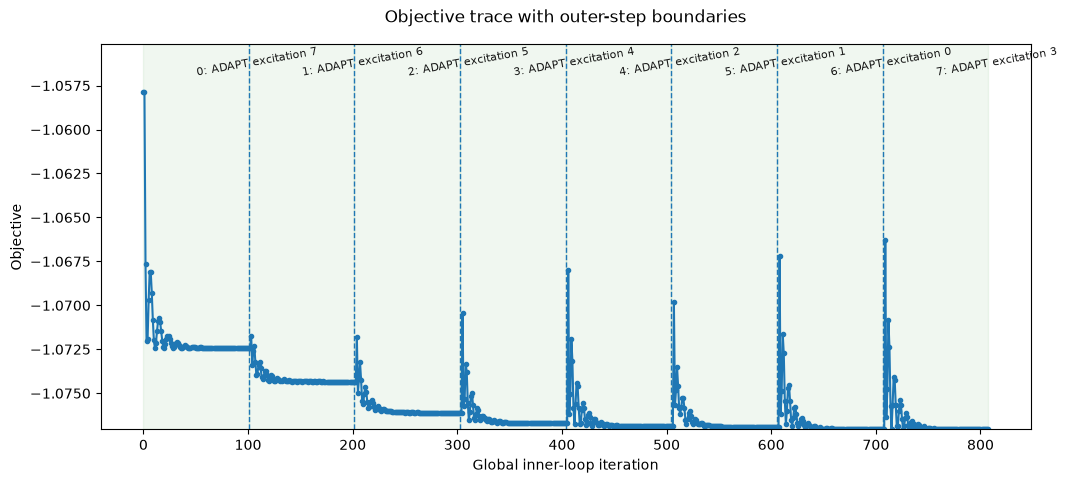

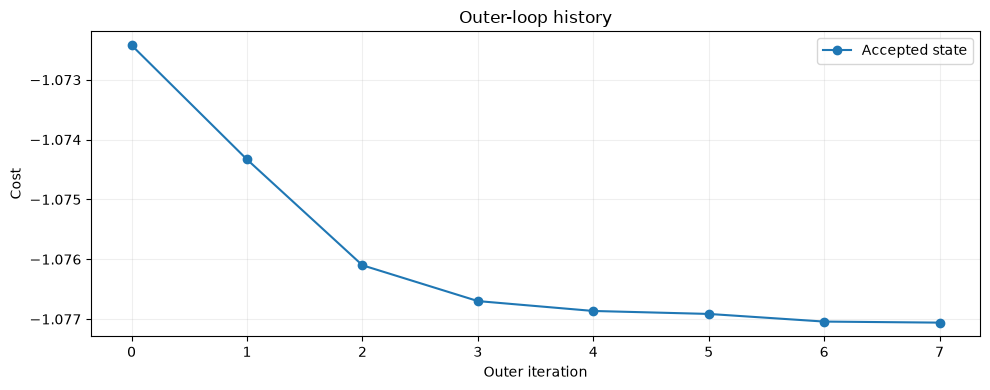

In [ ]:
experiment.recorder.plot_objective()
experiment.recorder.plot_parameter_heatmap(normalize=True)
experiment.plot_outer_history()

(<Figure size 5047x1022.33 with 2 Axes>,
 array([<Axes: title={'left': 'Outer iteration 0: ADAPT excitation 7'}>,
        <Axes: title={'left': 'Outer iteration 7: ADAPT excitation 3'}>],
       dtype=object))

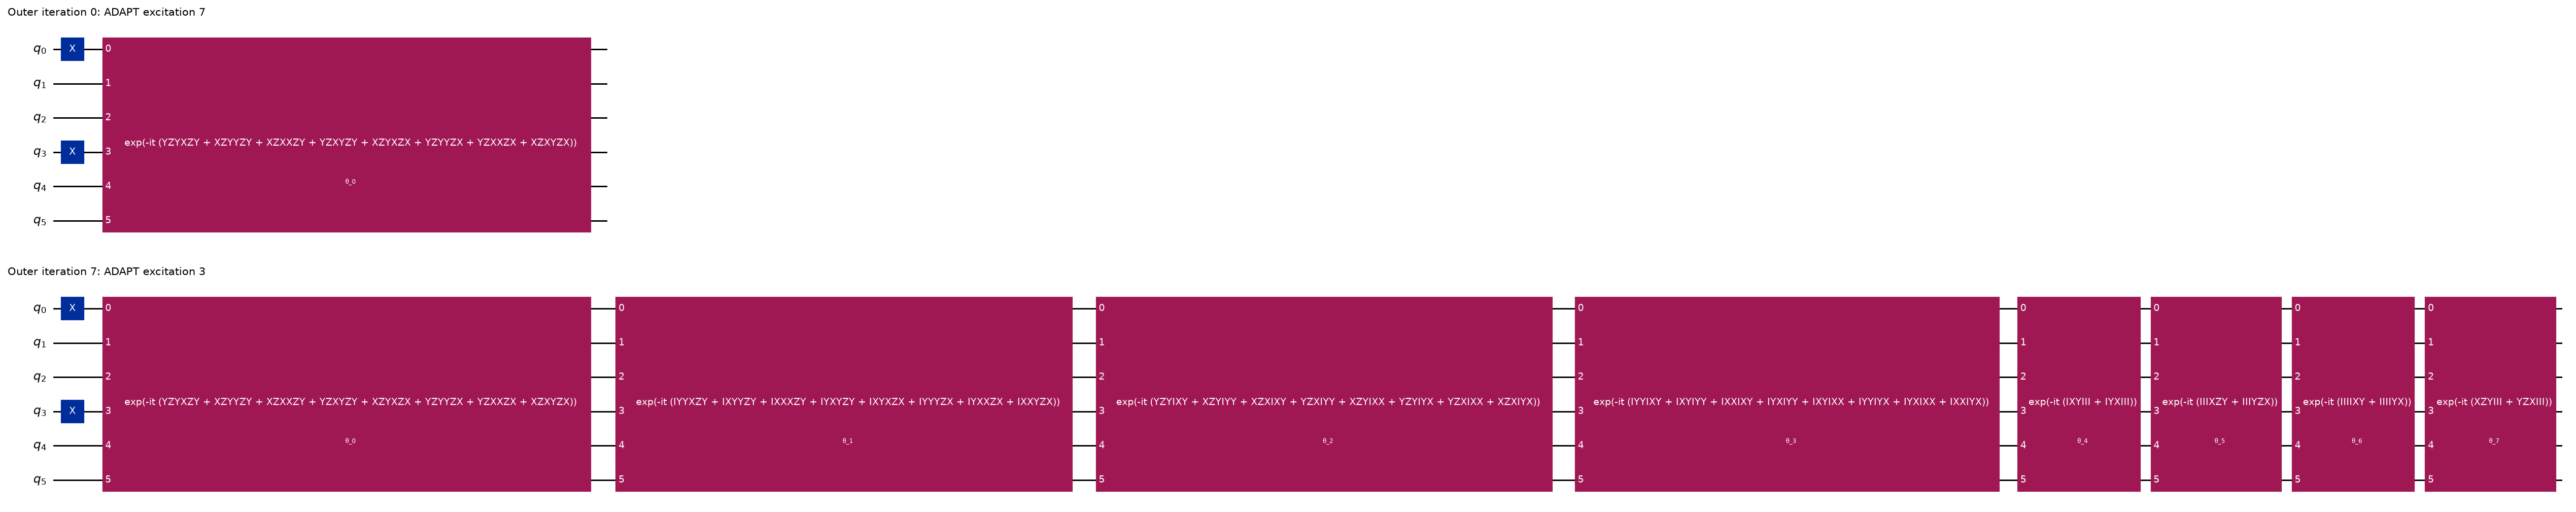

In [ ]:
experiment.plot_architecture_evolution(indices=[0, -1])